## EEE205 Artificial Intelligence I
# Part 11 - Polynomial regression
## Tutorial solutions
### Barry Dillon

**1 - In your own words, write down a definition of each of these concepts.**

Try writing the definitions first from memory, without checking notes or the internet.  Then check your notes/internet to improve what you have.  This is a good learning technique.

a - Regression

b - Features and target variables

c - Correlation

d - Here is the straight-line equation, $y=mx+c$, define what these are:
- y
- x
- m
- c

e - Quadratic equation

f - Polynomial equation

g - Turning point

h - Residual

i - Loss function

j - Overfitting

k - Underfitting

l - Train-test split

**2 - Reading up on python functionality**

When we work with python (or any language), we need to consult documentation to properly understand how the tools we are using work.  This is what you'll do in this question.

For each of the functions below, look up the documentation for the function online and give a short description of how it works.  i.e.
- what does it do?
- what are the inputs?
- what are the outputs?
- what are some of the parameters it takes?

a - The `train_test_split` function in `scikit-learn`

b - The `Pipeline` function

c - The `PolynomialFeatures` function

d - The `LinearRegression` function

e - The `r2_score` function

f - The `mean_squared_error` function

**3 - Now we will go through a polynomial regression example.**

The code below generates some data.  The data follows a cubic equation, plus some noise.  We are only using this data to understand how to do polynomial fits, it's not real data.  In machine-learning, we sometimes call this 'dummy data'.  `X` are the features and `y` are the labels.

In [1]:
# importing numpy
import numpy as np

# define number of data points we want
npoints = 50

# use numpy to get evenly spaced points for x
X = np.linspace(0, 5, npoints)

# get y points using a cubic equation + some noise (random numbers generated from numpy)
rng = np.random.default_rng(0)
y = 0.1 * X**3 - 0.6 * X**2 + 2 * X + rng.normal(0, 0.9, npoints)

a - Check the shapes of the data.

In [2]:
print("X shape:", X.shape)
print("y shape:", y.shape)  # should both be (50,) at this stage


X shape: (50,)
y shape: (50,)


The features must be arrays.  We can turn them into arrays using the below code:

In [3]:
X = X.reshape(-1,1)

In [4]:
print(X.shape)

(50, 1)


`X.reshape(N,M)` reshapes an array into an array of shape `(N,M)`, i.e. `N` rows and `M` columns.  When we put a `-1` in either of these places, numpy automatically figures out what the number should be based on the size of `X`.  So when we do `X.reshape(-1,1)` we reshape `X` into an array with 1 column, and a single row for each feature in the data.  So, 50 rows.

b - Make a scatter plot of this data.  Add axis labels and a grid, make the plot look relatively nice.

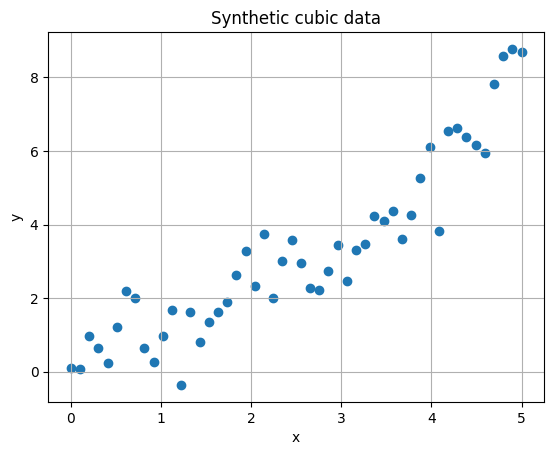

In [5]:
from matplotlib import pyplot as plt

plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic cubic data")
plt.grid(True)
plt.show()


c - Split the data into 75% training data and 25% testing data.

In [7]:
from sklearn.model_selection import train_test_split

X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=0.25, random_state=42)


d - Now check the shapes of the training and testing data (features and labels)

In [8]:
print("X_trn shape:", X_trn.shape)
print("y_trn shape:", y_trn.shape)
print("X_tst shape:", X_tst.shape)
print("y_tst shape:", y_tst.shape)


X_trn shape: (37, 1)
y_trn shape: (37,)
X_tst shape: (13, 1)
y_tst shape: (13,)


e - Use Pipeline, PolynomialFeatures, and LinearRegression to fit a polynomial of degree 1 to this data.  Call the model `model_1`.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degree = 1
model_1 = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("linreg", LinearRegression())
])
model_1.fit(X_trn, y_trn)

,steps,"[('poly', ...), ('linreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


f - Compute the r2 score of this model on both the training and testing data.  Call the result `r2_1`.

In [10]:
from sklearn.metrics import r2_score

In [11]:
# predictions for degree-1 model
y_trn_pred_1 = model_1.predict(X_trn)
y_tst_pred_1 = model_1.predict(X_tst)

r2_1_trn = r2_score(y_trn, y_trn_pred_1)
r2_1_tst = r2_score(y_tst, y_tst_pred_1)

print("Degree 1 - train R2:", r2_1_trn)
print("Degree 1 - test  R2:", r2_1_tst)


Degree 1 - train R2: 0.8501065865518127
Degree 1 - test  R2: 0.7963981546345023


g - Repeat parts e and f for degree = 2, 3, 4, 5, and 6.  Call the models `model_2`, `model_3`, `model_4`, ... . And call the scores `r2_2`, `r2_3`, `r2_4`, .... .

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# we already have degree 1 above
degrees = [2, 3, 4, 5, 6]

# store scores for plotting
train_scores = [r2_1_trn]
test_scores = [r2_1_tst]
degree_labels = [1]

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_trn, y_trn)

    # name the model as requested
    globals()[f"model_{d}"] = model

    y_trn_pred = model.predict(X_trn)
    y_tst_pred = model.predict(X_tst)

    r2_trn = r2_score(y_trn, y_trn_pred)
    r2_tst = r2_score(y_tst, y_tst_pred)

    # store individual r2 variables as requested
    globals()[f"r2_{d}_trn"] = r2_trn
    globals()[f"r2_{d}_tst"] = r2_tst

    train_scores.append(r2_trn)
    test_scores.append(r2_tst)
    degree_labels.append(d)

# quick check
for d, tr, te in zip(degree_labels, train_scores, test_scores):
    print(f"degree={d:>2}  train R2={tr:.3f}  test R2={te:.3f}")


degree= 1  train R2=0.850  test R2=0.796
degree= 2  train R2=0.910  test R2=0.868
degree= 3  train R2=0.926  test R2=0.875
degree= 4  train R2=0.927  test R2=0.879
degree= 5  train R2=0.927  test R2=0.877
degree= 6  train R2=0.936  test R2=0.862


h - Make a plot comparing these scores for different models.  You can choose the type of plot.

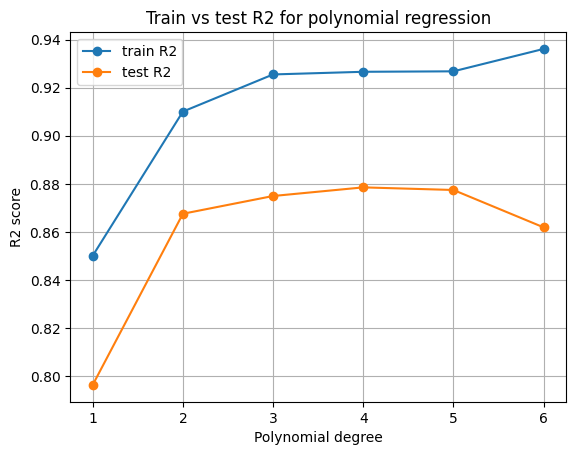

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(degree_labels, train_scores, marker="o", label="train R2")
plt.plot(degree_labels, test_scores, marker="o", label="test R2")
plt.xlabel("Polynomial degree")
plt.ylabel("R2 score")
plt.title("Train vs test R2 for polynomial regression")
plt.legend()
plt.grid(True)
plt.show()


As we increase the polynomial degree, the **training** R2 generally goes up (the model can fit the training data more and more closely).  
However, the **test** R2 improves only up to a point and then starts to drop.  
That drop means the model has begun to **overfit**: it is memorising noise in the training set instead of learning the true underlying pattern.  
So we should choose the degree where the test R2 is highest (often somewhere in the middle, not the largest degree).

**4 - Playing around with data fits**

On BBL there are three data files named `tutorial_data_1.csv`, `tutorial_data_2.csv`, and `tutorial_data_3.csv`.  For each of them, load them in python and try to get the best polynomial fit.  By **best** we mean the one with the best test score.  You could write write functions here that allow you to resuse code, instead of writing new code for every file...

Use 50/50 train-test splits here, to have more testing data.

Investigate at what point the models begin to **overfit**.

Here we load the data:

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("tutorial_data_1.csv")

We can check the columns, then extract the features and labels as numpy arrays.

In [16]:
df.columns

Index(['features', 'targets'], dtype='object')

In [17]:
X = df[['features']].values  # 2D array, shape (N, 1)

In [18]:
y = df['targets'].values    # 1D array, shape (N,)

Run the code above for each of the three CSV files.  
Look for the degree where the **test** R2 is highest — that is your “best” polynomial model for that dataset.  
You should see that very high degrees give perfect (or near‑perfect) train scores but **worse** test scores: that’s overfitting in action.

--- tutorial_data_1.csv ---


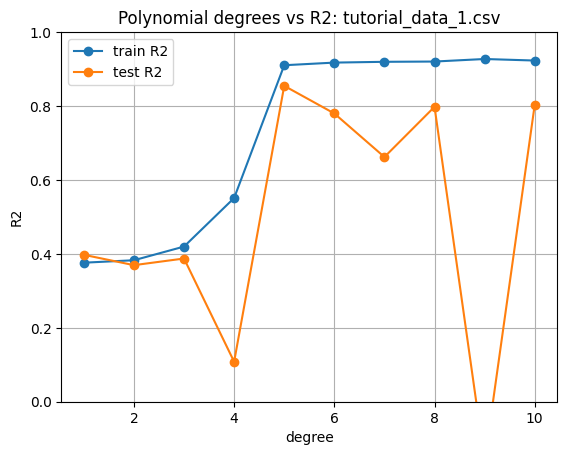

Best degree by test R2: 5 with R2=0.855
--- tutorial_data_2.csv ---


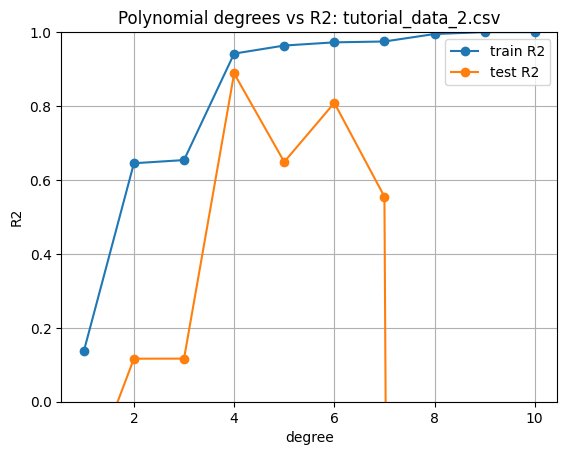

Best degree by test R2: 4 with R2=0.888
--- tutorial_data_3.csv ---


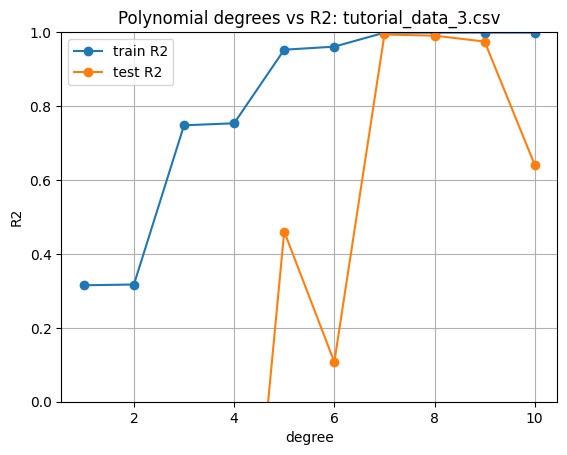

Best degree by test R2: 7 with R2=0.994


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def evaluate_dataset(path, max_degree=10):
    print(f"--- {path} ---")
    df = pd.read_csv(path)
    X = df[['features']].values
    y = df['targets'].values

    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=0.5, random_state=55)

    degrees = list(range(1, max_degree + 1))
    train_scores = []
    test_scores = []

    for d in degrees:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("linreg", LinearRegression())
        ])
        model.fit(X_trn, y_trn)

        y_trn_pred = model.predict(X_trn)
        y_tst_pred = model.predict(X_tst)

        train_scores.append(r2_score(y_trn, y_trn_pred))
        test_scores.append(r2_score(y_tst, y_tst_pred))

    # plot for this dataset
    plt.figure()
    plt.plot(degrees, train_scores, marker="o", label="train R2")
    plt.plot(degrees, test_scores, marker="o", label="test R2")
    plt.ylim(0,1)
    plt.title(f"Polynomial degrees vs R2: {path}")
    plt.xlabel("degree")
    plt.ylabel("R2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # print the best test score
    best_idx = max(range(len(test_scores)), key=lambda i: test_scores[i])
    print(f"Best degree by test R2: {degrees[best_idx]} with R2={test_scores[best_idx]:.3f}")

# try all three files (they must be present in the working directory)
for fname in ["tutorial_data_1.csv", "tutorial_data_2.csv", "tutorial_data_3.csv"]:
    try:
        evaluate_dataset(fname, max_degree=10)
    except FileNotFoundError:
        print(f"File {fname} not found here, but this is the code you should run when you have it.")


Vary the random state in test_train_split to see how this changes things...

This is what happens when we have very little data.